In [65]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Data loading and initial assessment

In [20]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
df.shape

(891, 12)

In [22]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [23]:
df.isna().sum()/df.shape[0]*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [24]:
df.duplicated().sum()

0

In [25]:
df.info(memory_usage=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)

# Data cleaning

In [26]:
df.head(0)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [27]:
for c in df.columns:
    print(f"{c}    :    {df[c].isna().sum()}    :    {df[c].nunique()}    :    {df[c].dtypes}")

PassengerId    :    0    :    891    :    int64
Survived    :    0    :    2    :    int64
Pclass    :    0    :    3    :    int64
Name    :    0    :    891    :    object
Sex    :    0    :    2    :    object
Age    :    177    :    88    :    float64
SibSp    :    0    :    7    :    int64
Parch    :    0    :    7    :    int64
Ticket    :    0    :    681    :    object
Fare    :    0    :    248    :    float64
Cabin    :    687    :    147    :    object
Embarked    :    2    :    3    :    object


In [28]:
df = df.drop(columns=['PassengerId','Cabin'])
df.shape

(891, 10)

In [29]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    2
dtype: int64

In [30]:
df['Embarked'] = df['Embarked'].fillna(df["Embarked"].mode()[0])
df.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [31]:
for c in df.columns:
    print(f"{c}    :    {df[c].isna().sum()}    :    {df[c].nunique()}    :    {df[c].dtypes}")

Survived    :    0    :    2    :    int64
Pclass    :    0    :    3    :    int64
Name    :    0    :    891    :    object
Sex    :    0    :    2    :    object
Age    :    0    :    88    :    float64
SibSp    :    0    :    7    :    int64
Parch    :    0    :    7    :    int64
Ticket    :    0    :    681    :    object
Fare    :    0    :    248    :    float64
Embarked    :    0    :    3    :    object


In [32]:
df['Name'].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

In [33]:
df = df.drop(columns=['Name'])
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked'],
      dtype='object')

In [34]:
for c in df.columns:
    print(f"{c}    :    {df[c].isna().sum()}    :    {df[c].nunique()}    :    {df[c].dtypes}")

Survived    :    0    :    2    :    int64
Pclass    :    0    :    3    :    int64
Sex    :    0    :    2    :    object
Age    :    0    :    88    :    float64
SibSp    :    0    :    7    :    int64
Parch    :    0    :    7    :    int64
Ticket    :    0    :    681    :    object
Fare    :    0    :    248    :    float64
Embarked    :    0    :    3    :    object


In [35]:
df['Ticket'].sample(20)

245              19928
17              244373
544           PC 17761
644               2666
357             237671
193             230080
509               1601
699             348121
48                2662
75              348123
136              11752
567             349909
378               2648
239         SCO/W 1585
387              27849
599           PC 17485
817    S.C./PARIS 2079
70          C.A. 33111
770             345781
496              36947
Name: Ticket, dtype: object

In [36]:
df = df.drop(columns=['Ticket'])
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

# Exploratory Data analysis

In [38]:
numeric = df._get_numeric_data()
numeric.dtypes

Survived      int64
Pclass        int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
dtype: object

In [39]:
for c in numeric.columns:
    print(c,":",numeric[c].skew())
    

Survived : 0.4785234382949897
Pclass : -0.6305479068752843
Age : 0.5102446555756496
SibSp : 3.6953517271630556
Parch : 2.7491170471010933
Fare : 4.787316519674893


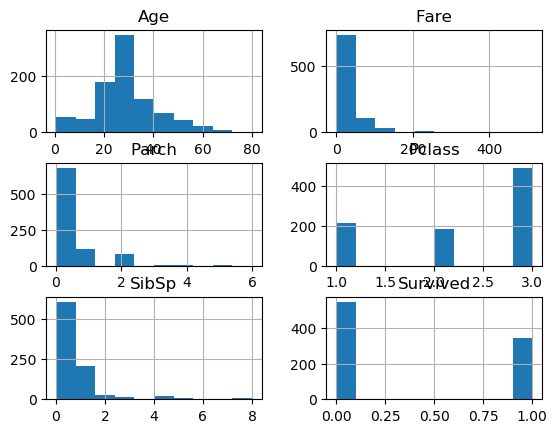

In [43]:
numeric.hist()
plt.show()

In [48]:
numeric.corr()['Survived']

Survived    1.000000
Pclass     -0.338481
Age        -0.064910
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Name: Survived, dtype: float64

# preprocessing

In [54]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [56]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train = pd.get_dummies(x_train,columns=["Sex","Embarked"]) 
x_test = pd.get_dummies(x_test,columns=["Sex","Embarked"])

# model training

In [64]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
p_test = model.predict(x_test)
p_train = model.predict(x_train)

# evaluation

In [66]:
accuracy_test = accuracy_score(y_test,p_test)
accuracy_train = accuracy_score(y_train,p_train)
cm_test = confusion_matrix(y_test,p_test)
cm_train = confusion_matrix(y_train,p_train)

In [67]:
print("accuracy test:",accuracy_test)
print("accuracy train:",accuracy_train)

print("cm train:")
print(cm_train)

print("cm test:")
print(cm_test)

accuracy test: 0.8100558659217877
accuracy train: 0.800561797752809
cm train:
[[384  60]
 [ 82 186]]
cm test:
[[90 15]
 [19 55]]


In [68]:
print("test")
print(classification_report(y_test,p_test))

print("train")
print(classification_report(y_train,p_train))

test
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

train
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       444
           1       0.76      0.69      0.72       268

    accuracy                           0.80       712
   macro avg       0.79      0.78      0.78       712
weighted avg       0.80      0.80      0.80       712

